In [ ]:
from bqskit.ir.gates import RZZGate as b_rzz
from bqskit.ir.gates import U3Gate as b_u3
from bqskit import MachineModel
from bqskit.qis import UnitaryMatrix
from qiskit.quantum_info.random import random_unitary
from bqskit import compile

bqskit_model = MachineModel(2, gate_set={b_rzz(), b_u3()})
u_target = random_unitary(4, seed=0)
bqskit_output = compile(UnitaryMatrix(u_target.to_matrix()), model=bqskit_model)
sum(bqskit_output.gate_counts.values()) - bqskit_output.gate_counts[b_u3()]

3

In [ ]:
s = 0
for g in bqskit_output:
    if g._gate == b_rzz():
        s += g.params[0]
print(s)

11.29437265284538


In [ ]:
from gulps.core.invariants import GateInvariants
from qiskit.circuit.library import RZZGate
from gulps.cts_linear_program import ContinuousISAConstraints
import numpy as np

base = GateInvariants.from_unitary(RZZGate(theta=np.pi / 2))
solver = ContinuousISAConstraints(base=base, sequence_length=8, offset=1e-6)
target = GateInvariants.from_unitary(u_target)
solver.set_target(target, rho_bool=False)
gi_list, intermediates, ks = solver.solve(log_output=False)
print(ks, sum(ks))

[0.6263015133063183, 0.6263015133063183, 0.32209976695259357] 1.5747027935652302


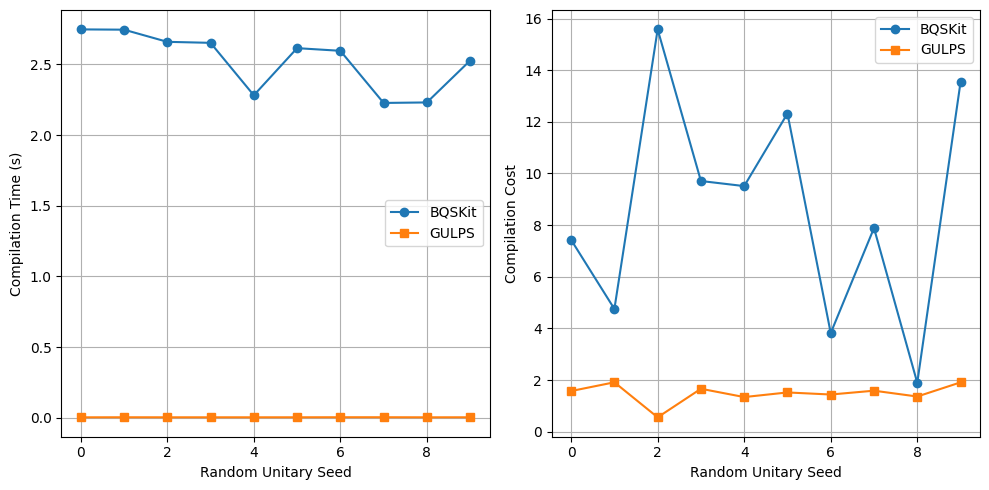

In [ ]:
from time import perf_counter
import numpy as np
import matplotlib.pyplot as plt

# Initialize models
bqskit_model = MachineModel(2, gate_set={b_rzz(), b_u3()})
results = []

# Sweep over random unitaries
for seed in range(10):
    u_target = random_unitary(4, seed=seed)

    # BQSKit Compilation
    try:
        t0 = perf_counter()
        bqskit_output = compile(UnitaryMatrix(u_target.to_matrix()), model=bqskit_model)
        t1 = perf_counter()

        # Calculate cost (sum of RZZ params)
        s = 0
        for g in bqskit_output:
            if g._gate == b_rzz():
                s += g.params[0]

        results.append(("bqskit", seed, t1 - t0, s))
    except Exception as e:
        print(f"BQSKit failed for seed {seed}: {e}")
        results.append(("bqskit", seed, None, None))

    # GULPS Compilation
    try:
        base = GateInvariants.from_unitary(RZZGate(theta=np.pi / 2))
        solver = ContinuousISAConstraints(base=base, sequence_length=8, offset=1e-6)
        target = GateInvariants.from_unitary(u_target)
        solver.set_target(target, rho_bool=False)

        t0 = perf_counter()
        gi_list, intermediates, ks = solver.solve(log_output=False)
        t1 = perf_counter()

        results.append(("gulps", seed, t1 - t0, sum(ks)))
    except Exception as e:
        print(f"GULPS failed for seed {seed}: {e}")
        results.append(("gulps", seed, None, None))

# Organize results
bqskit_times = [r[2] for r in results if r[0] == "bqskit"]
bqskit_costs = [r[3] for r in results if r[0] == "bqskit"]
gulps_times = [r[2] for r in results if r[0] == "gulps"]
gulps_costs = [r[3] for r in results if r[0] == "gulps"]

# Plot results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(10), bqskit_times, label="BQSKit", marker="o")
plt.plot(range(10), gulps_times, label="GULPS", marker="s")
plt.xlabel("Random Unitary Seed")
plt.ylabel("Compilation Time (s)")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(10), bqskit_costs, label="BQSKit", marker="o")
plt.plot(range(10), gulps_costs, label="GULPS", marker="s")
plt.xlabel("Random Unitary Seed")
plt.ylabel("Compilation Cost")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()